## Python Data fitting with various functions - HW 12
Due Monday Dec 1, 2025



Dowload the data "miniDR17.fits" from the TCU Online Week 14:<br>
<i>NOTE: it is a large-ish file and may take a while.</i>

**However, this is a small version of the full science data file (4 GB) which can be found at:**<br>
https://data.sdss.org/sas/dr17/apogee/spectro/aspcap/dr17/synspec_rev1/allStar-dr17-synspec_rev1.fits


My example below will show how to remove Identified bad data, 
however data that are just bad in one quantity may remain

_Use masking to remove any remaining bad values (typically 9999 or -9999 in this file_ , <b>but check!!!! If you are not sure, ask!!!</b>). 

In [11]:
from matplotlib import pyplot as plt
import numpy as np
from astropy.io import fits 
import scipy.optimize as opt

# POTENTIAL FITTING FUNCTIONS
def linear(x,m,b):
    return m*x+b

def poly2(x,a,b,c):
    return a*(x**2)+(b*x)+c

def poly3(x,a,b,c,d):
    return (a*(x**3))+(b*(x**2))+(c*x)+d

def cosfit (x,a,b,c,d):
    return a*np.cos(b*x + c) + d

def exponential(x,a,b,c,d):
    return a*np.exp(b*x + c) + d


# Monte Carlo-version of 2 parameter Curve Fit that can use BOTH x and Y errors
def mcFit2(func, x, y, x_err=0.1, y_err=0.1, p0=[0,0]):
    slope = list()
    y_ints = list()
    iters = 500 
    for i in range(iters):
        # remember random normal distribution (Gaussian)
        weightsx = np.random.randn(len(y))
        weightsy = np.random.randn(len(y))
        y_adj = y + y_err*weightsy
        x_adj = x + x_err*weightsx 
        popt, pcov = opt.curve_fit(func, x_adj, y_adj, p0=p0)
        slope.append(popt[0])
        y_ints.append(popt[1])
    return (np.median(slope),np.median(y_ints))


# Monte Carlo-version of 3 parameter Curve Fit that can use BOTH x and Y errors
def mcFit3(func, x, y, x_err=0.1, y_err=0.1,p0=[1,1,1]):
    paramA = list()
    paramB = list()
    paramC = list()
    iters = 500 
    for i in range(iters):
        # remember random normal distribution (Gaussian)
        weightsx = np.random.randn(len(y))
        weightsy = np.random.randn(len(y))
        y_adj = y + y_err*weightsy
        x_adj = x + x_err*weightsx 
        popt, pcov = opt.curve_fit(func, x_adj, y_adj, p0=p0)
        paramA.append(popt[0])
        paramB.append(popt[1])
        paramC.append(popt[2])
    return (np.median(paramA),np.median(paramB),np.median(paramC))

# Monte Carlo-version of 4 parameter Curve Fit that can use BOTH x and Y errors
def mcFit4(func, x, y, x_err=0.1, y_err=0.1, p0=[1,1,1,1]):
    paramA = list()
    paramB = list()
    paramC = list()
    paramD = list()
    iters = 500 
    for i in range(iters):
        # remember random normal distribution (Gaussian)
        weightsx = np.random.randn(len(y))
        weightsy = np.random.randn(len(y))
        y_adj = y + y_err*weightsy
        x_adj = x + x_err*weightsx 
        popt, pcov = opt.curve_fit(func, x_adj, y_adj, p0=p0)
        paramA.append(popt[0])
        paramB.append(popt[1])
        paramC.append(popt[2])
        paramD.append(popt[3])
    return (np.median(paramA),np.median(paramB),np.median(paramC),np.median(paramD))


In [12]:
# READ IN FITS FILES
star_hdus = fits.open('miniDR17.fits')
star = star_hdus[1].data
print(star_hdus[1].columns)
star_hdus.close()

ColDefs(
    name = 'APOGEE_ID'; format = '30A'
    name = 'RA'; format = 'D'
    name = 'DEC'; format = 'D'
    name = 'GLON'; format = 'D'
    name = 'GLAT'; format = 'D'
    name = 'TEFF'; format = 'E'
    name = 'TEFF_ERR'; format = 'E'
    name = 'LOGG'; format = 'E'
    name = 'LOGG_ERR'; format = 'E'
    name = 'J'; format = 'E'
    name = 'J_ERR'; format = 'E'
    name = 'K'; format = 'E'
    name = 'K_ERR'; format = 'E'
    name = 'SNR'; format = 'E'
    name = 'VHELIO_AVG'; format = 'E'
    name = 'VERR'; format = 'E'
    name = 'FE_H'; format = 'E'
    name = 'FE_H_ERR'; format = 'E'
    name = 'O_FE'; format = 'E'
    name = 'O_FE_ERR'; format = 'E'
    name = 'NI_FE'; format = 'E'
    name = 'NI_FE_ERR'; format = 'E'
    name = 'NVISITS'; format = 'J'
    name = 'VSCATTER'; format = 'E'
    name = 'ASPCAPFLAG'; format = 'K'
    name = 'STARFLAG'; format = 'K'
    name = 'EXTRATARG'; format = 'J'
    name = 'GAIA_PARALLAX'; format = 'E'
    name = 'GAIA_PARALLAX_ERROR'; for

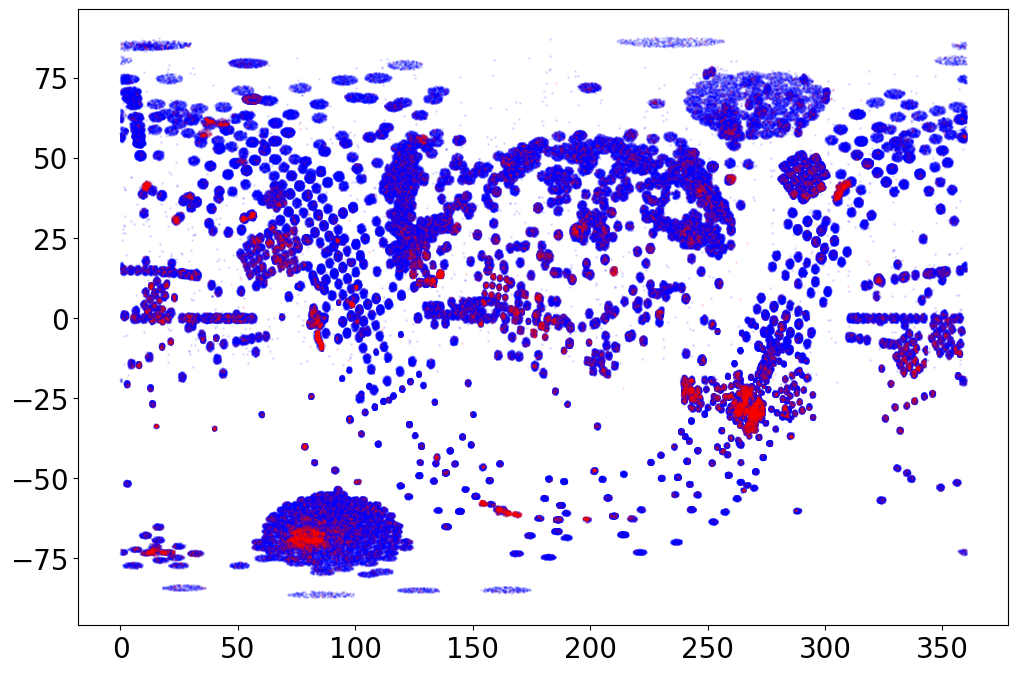

In [13]:
# TWO BITWISE FLAGS FOR BAD DATA - THESE REMOVE IDENTIFIED BAD DATA            
badbits = 2**23        # aspcapstar flag - Chemistry
suspectbits = 2**16    # star flag - Stellar parameters

# Make a Boolena Mask to remove bad data
gd = (np.bitwise_and(star['aspcapflag'], badbits) == 0) &\
     (np.bitwise_and(star['starflag'], suspectbits) == 0) 
bd = (np.bitwise_and(star['aspcapflag'], badbits) != 0) |\
     (np.bitwise_and(star['starflag'], suspectbits) != 0) 

good = np.where(gd)[0]
bad = np.where(bd)[0]

# PLOT TO VERIFY FITS FILE READ IN & BAD MASK DATA
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)
ax.scatter(star['RA'][good],star['DEC'][good],s=1,c='b',alpha=0.1)
ax.scatter(star['RA'][bad],star['DEC'][bad],s=1,c='r',alpha=0.1)


ax.xaxis.set_tick_params(labelsize=20)
ax.yaxis.set_tick_params(labelsize=20)
plt.show()

LINEAR: -0.074, 16.223
POLY2: 0.005, -1.877, 130.634
COSFIT: 72.947, 0.018, -0.452, -5.700


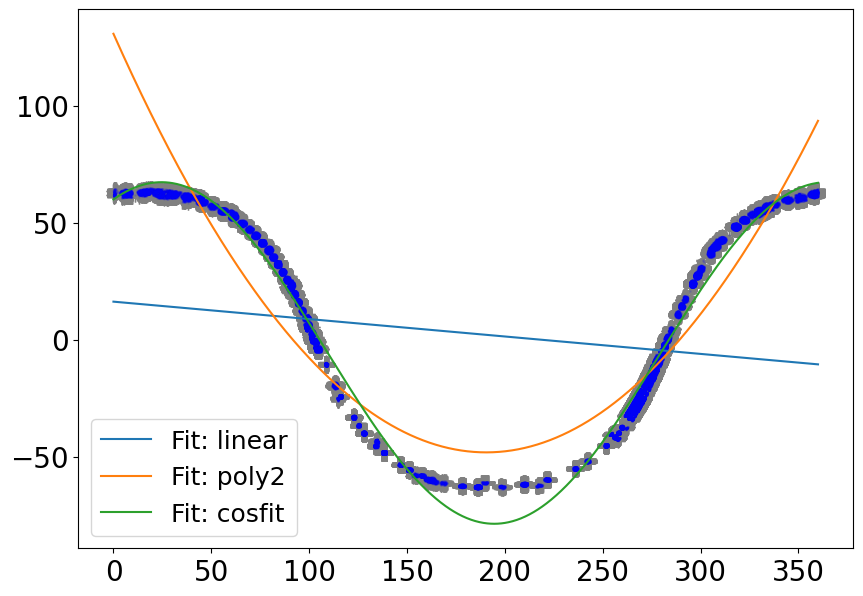

In [14]:
# EXAMPLE FIT - DR. FRINCHABOY
# --------------------------------------------
# First use Linear, Polnomial, and Cosine Fits
# Select stars only with with  −2 < GLAT < 2   
# 
# I FIT RA & DEC data versus LINEAR, POLY2, AND COSFIT in this example.  
#
# TWO BITWISE FLAGS TO REMOVE FOR OBVIOUSLY BAD DATA             
badbits = 2**23        # aspcapstar flag - Chemistry
suspectbits = 2**16    # star flag - Stellar parameters

#=================================================================================
# Make a Boolena Mask to remove bad data - AND ANY OTHER NEEDED CUTS 
# (e.g., −2 < GLAT < 2 ) or other 'bad' data not removed by the flags.
ct1 = (np.bitwise_and(star['aspcapflag'], badbits) == 0) & \
     (np.bitwise_and(star['starflag'], suspectbits) == 0) & \
     (star['GLAT'] < 2) &\
     (star['GLAT'] > -2) 
cut1 = np.where(ct1)[0]

#=================================================================================
## LINEAR FIT (2 parameter)
slope, intercept = mcFit2(linear, star['RA'][cut1], star['DEC'][cut1], 0.001, \
                          0.001, p0=[0,0])
print(f'LINEAR: {slope:.3f}, {intercept:.3f}')

#=================================================================================
## POLY2 FIT (3 parameter)
polyA, polyB, polyC,  = mcFit3(poly2, star['RA'][cut1], star['DEC'][cut1], 0.001, \
                         0.001,p0=[600,1,1])
print(f'POLY2: {polyA:.3f}, {polyB:.3f}, {polyC:.3f}')

#=================================================================================
## COS FIT (4 parameter)
cfA, cfB, cfC, cfD = mcFit4(cosfit, star['RA'][cut1], star['DEC'][cut1], 0.001, \
                            0.001,p0=[60,0.02,0,0])
print(f'COSFIT: {cfA:.3f}, {cfB:.3f}, {cfC:.3f}, {cfD:.3f}')
#=================================================================================



# PLOT TO VERIFY FITS FILE READ IN & BAD MASK DATA
fig1 = plt.figure(figsize=(10,7))
ax1 = fig1.add_subplot(111)
ax1.xaxis.set_tick_params(labelsize=20)
ax1.yaxis.set_tick_params(labelsize=20)

# PLOT DATA AND ERROR BARS
ax1.scatter(star['RA'][cut1],star['DEC'][cut1],s=1,c='b',alpha=0.1)
ax1.errorbar((star['RA'][cut1]),star['DEC'][cut1], xerr=(0.001),
             yerr=(0.001), ecolor='grey',fmt='none', capsize=5, zorder=0)


#=================================================================================
# PLOT DATA FITS FROM ABOVE
x_plot = np.linspace(0,360,1000) # X-PLOTING FOR FITS

#=================================================================================
#linear fit
ax1.plot(x_plot,linear(x_plot, slope, intercept), label='Fit: linear')
#poly2 fit
ax1.plot(x_plot,poly2(x_plot, polyA, polyB, polyC), label='Fit: poly2')
#cosfit
ax1.plot(x_plot,cosfit(x_plot, cfA, cfB, cfC, cfD), label='Fit: cosfit')

plt.legend(loc='best', fontsize=18)
plt.show()

# Homework #12

**REMINDER:** *All coding assignment will be turned in as .ipynb files, to the same PHYS_X0223 repository on GitHub.*   
*They should be turned in with the following naming:*
    
    Lastname_Firstinitial_24_HW12a.ipynb

## DATA FIT 1

Fit a linear, polynomial (poly2), and a polynomial (poly3) functions and to the following selections of the data:
1. Select stars only with with $ GLAT > 20$ <br>
   __Fit Fe\_H,  (Fe\_H\_ERR)  vs.  O\_FE (O\_FE\_ERR)__<br>

For this fit of the above selection:

1. What are the best-fit values of the parameters?
   / Answer:
    LINEAR: -0.233, 0.054
    POLY2: -0.073, -0.317, 0.048
    POLY3: 0.075, 0.092, -0.262, 0.045
3. Which function fits the data best?
   / Answer: Poly3
4. Is there a second population? (Can you fit outliers with a reasonable linear trend?)
   / Answer: Yes, there is a second population.

LINEAR: -0.233, 0.054
POLY2: -0.073, -0.317, 0.048
POLY3: 0.075, 0.092, -0.262, 0.045


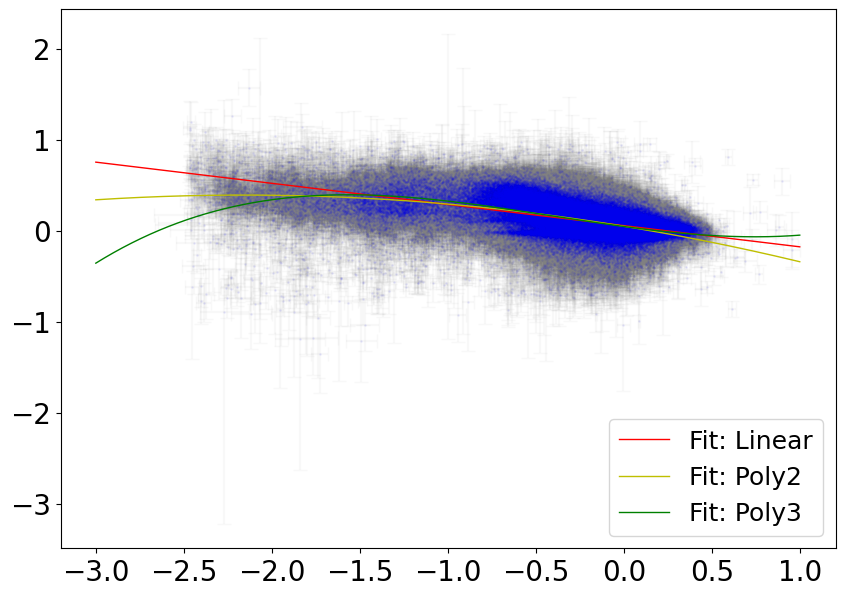

In [8]:
#DATA FIT 1

# TWO BITWISE FLAGS TO REMOVE FOR OBVIOUSLY BAD DATA             
badbits = 2**23        # aspcapstar flag - Chemistry
suspectbits = 2**16    # star flag - Stellar parameters

#=================================================================================
# Make a Boolean Mask to remove bad data - AND ANY OTHER NEEDED CUTS 
# (e.g., −2 < GLAT < 2 ) or other 'bad' data not removed by the flags.
ct1 = (np.bitwise_and(star['aspcapflag'], badbits) == 0) & \
     (np.bitwise_and(star['starflag'], suspectbits) == 0) & \
     (star['GLAT'] > 20) & (~np.isnan(star['FE_H_ERR'])) & (~np.isnan(star['O_FE_ERR']))
cut1 = np.where(ct1)[0]

#=================================================================================
## LINEAR FIT (2 parameter)
slope, intercept = mcFit2(linear, star['FE_H'][cut1], star['O_FE'][cut1], star['FE_H_ERR'][cut1], \
                          star['O_FE_ERR'][cut1], p0=[0,0])
print(f'LINEAR: {slope:.3f}, {intercept:.3f}')

#=================================================================================
## POLY2 FIT (3 parameter)
poly2A, poly2B, poly2C,  = mcFit3(poly2, star['FE_H'][cut1], star['O_FE'][cut1], star['FE_H_ERR'][cut1], \
                                  star['O_FE_ERR'][cut1],p0=[600,1,1])
print(f'POLY2: {poly2A:.3f}, {poly2B:.3f}, {poly2C:.3f}')

#=================================================================================
## POLY3 FIT (4 parameter)
poly3A, poly3B, poly3C, poly3D = mcFit4(poly3, star['FE_H'][cut1], star['O_FE'][cut1], star['FE_H_ERR'][cut1], \
                          star['O_FE_ERR'][cut1],p0=[60,0.02,0,0])
print(f'POLY3: {poly3A:.3f}, {poly3B:.3f}, {poly3C:.3f}, {poly3D:.3f}')
#=================================================================================


# PLOT TO VERIFY FITS FILE READ IN & BAD MASK DATA
fig1 = plt.figure(figsize=(10,7))
ax1 = fig1.add_subplot(111)
ax1.xaxis.set_tick_params(labelsize=20)
ax1.yaxis.set_tick_params(labelsize=20)

# PLOT DATA AND ERROR BARS
ax1.scatter(star['FE_H'][cut1],star['O_FE'][cut1],s=1,c='b',alpha=0.05)
ax1.errorbar((star['FE_H'][cut1]),star['O_FE'][cut1], xerr=((star['FE_H_ERR'][cut1])),
             yerr=((star['O_FE_ERR'][cut1])), ecolor='grey',fmt='none', alpha=0.05, capsize=5, zorder=0)


#=================================================================================
# PLOT DATA FITS FROM ABOVE
x_plot = np.linspace(-3,1,1000) # X-PLOTING FOR FITS
#y_plot = np.linspace(-1,1,1000)

#=================================================================================
#linear fit
ax1.plot(x_plot, linear(x_plot, slope, intercept), 'r-', lw=1, label='Fit: Linear')
#p
ax1.plot(x_plot, poly2(x_plot, poly2A, poly2B, poly2C), 'y-', lw=1, label='Fit: Poly2')
ax1.plot(x_plot, poly3(x_plot, poly3A, poly3B, poly3C, poly3D), 'g-', lw=1, label='Fit: Poly3')

plt.legend(loc='best', fontsize=18)
plt.show()

## DATA FIT 2

Fit a linear, polynomial (poly2), and a polynomial (poly3) functions and to the following selections of the data:
2. Select stars only with with $-1< GLAT < 1$ <br>
   __Fit Fe\_H,  (Fe\_H\_ERR)  vs.  O\_FE (O\_FE\_ERR)__<br>

For this fit of the above selection:

1. What are the best-fit values of the parameters?
   / Answer:
   LINEAR: -0.137, 0.040
   POLY2: -0.020, -0.146, 0.041
   POLY3: 0.089, 0.129, -0.131, 0.033
3. Which fucntion fits the data best?
   / Answer: Poly3
5. Is there a second population? (Can you fit outliers with a reasonable linear trend?)
   / Answer: No, there is not a second population

LINEAR: -0.137, 0.040
POLY2: -0.020, -0.146, 0.041
POLY3: 0.090, 0.129, -0.131, 0.033


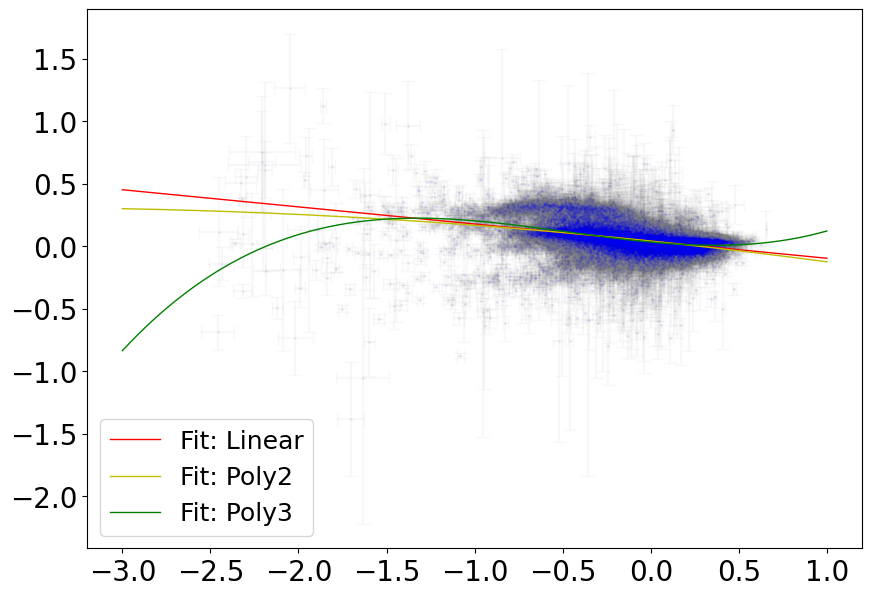

In [9]:
# write your fitting code, from part 1, and plot the results here
badbits = 2**23        # aspcapstar flag - Chemistry
suspectbits = 2**16    # star flag - Stellar parameters

#=================================================================================
# Make a Boolena Mask to remove bad data - AND ANY OTHER NEEDED CUTS 
# (e.g., −2 < GLAT < 2 ) or other 'bad' data not removed by the flags.
ct1 = (np.bitwise_and(star['aspcapflag'], badbits) == 0) & \
     (np.bitwise_and(star['starflag'], suspectbits) == 0) & \
     (star['GLAT'] < 1) &\
     (star['GLAT'] > -1) & (~np.isnan(star['FE_H_ERR'])) & (~np.isnan(star['O_FE_ERR']))
cut1 = np.where(ct1)[0]


#=================================================================================
## LINEAR FIT (2 parameter)
slope, intercept = mcFit2(linear, star['FE_H'][cut1], star['O_FE'][cut1], star['FE_H_ERR'][cut1], \
                          star['O_FE_ERR'][cut1], p0=[0,0])
print(f'LINEAR: {slope:.3f}, {intercept:.3f}')

#=================================================================================
## POLY2 FIT (3 parameter)
poly2A, poly2B, poly2C,  = mcFit3(poly2, star['FE_H'][cut1], star['O_FE'][cut1], star['FE_H_ERR'][cut1], \
                          star['O_FE_ERR'][cut1],p0=[600,1,1])
print(f'POLY2: {poly2A:.3f}, {poly2B:.3f}, {poly2C:.3f}')

#=================================================================================
## POLY3 FIT (4 parameter)
poly3A, poly3B, poly3C, poly3D = mcFit4(poly3, star['FE_H'][cut1], star['O_FE'][cut1], star['FE_H_ERR'][cut1], \
                          star['O_FE_ERR'][cut1],p0=[60,0.02,0,0])
print(f'POLY3: {poly3A:.3f}, {poly3B:.3f}, {poly3C:.3f}, {poly3D:.3f}')
#=================================================================================


# PLOT TO VERIFY FITS FILE READ IN & BAD MASK DATA
fig1 = plt.figure(figsize=(10,7))
ax1 = fig1.add_subplot(111)
ax1.xaxis.set_tick_params(labelsize=20)
ax1.yaxis.set_tick_params(labelsize=20)

# PLOT DATA AND ERROR BARS
ax1.scatter(star['FE_H'][cut1],star['O_FE'][cut1],s=1,c='b',alpha=0.05)
ax1.errorbar((star['FE_H'][cut1]),star['O_FE'][cut1], xerr=((star['FE_H_ERR'][cut1])),
             yerr=((star['O_FE_ERR'][cut1])), ecolor='grey',fmt='none', alpha=0.05, capsize=5, zorder=0)


#=================================================================================
# PLOT DATA FITS FROM ABOVE
x_plot = np.linspace(-3,1,1000) # X-PLOTING FOR FITS
#y_plot = np.linspace(-1,1,1000)

#=================================================================================
#linear fit
ax1.plot(x_plot, linear(x_plot, slope, intercept), 'r-', lw=1, label='Fit: Linear')
#p
ax1.plot(x_plot, poly2(x_plot, poly2A, poly2B, poly2C), 'y-', lw=1, label='Fit: Poly2')
ax1.plot(x_plot, poly3(x_plot, poly3A, poly3B, poly3C, poly3D), 'g-', lw=1, label='Fit: Poly3')

plt.legend(loc='best', fontsize=18)
plt.show()

## DATA FIT 3

Fit a linear, polynomial (poly3), and a exponetial functions and to the following selections of the data:
3. Select stars only with with $340 < GLON < 360$ <br>
   __Fit TEFF,  (TEFF\_ERR)  vs.  LOGG (LOGG\_ERR)__<br>

For this fit of the above selection:

1. What are the best-fit values of the parameters? 
   / Answer: LINEAR: 0.000, 0.354
     POLY3: 0.000, -0.000, 0.002, -4.025
     EXP: 675.713, 0.000, -675.702, 2.436
4. Which fucntion fits the data best? / Answer: The Exponential Function
5. Is there a second population? (Can you fit outliers with a reasonable linear trend?) / Answer: No there is no second population.

LINEAR: 0.000, 0.354
POLY3: 0.000, -0.000, 0.002, -4.025
EXP: 675.713, 0.000, -675.702, 2.436


/var/folders/_d/h91ts4dx0k98hbqgv6fl9sqw0000gn/T/ipykernel_95364/30161440.py:35: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_exp, pcov_exp = opt.curve_fit(exponential,


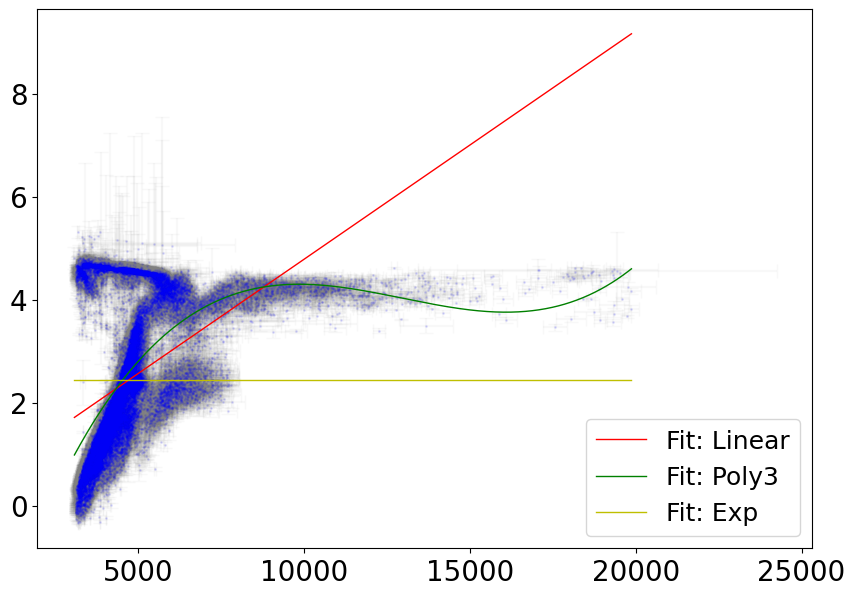

In [21]:
# write your fitting code and plot the results here

badbits = 2**23        # aspcapstar flag - Chemistry
suspectbits = 2**16    # star flag - Stellar parameters

#=================================================================================
# Make a Boolean Mask to remove bad data - AND ANY OTHER NEEDED CUTS 
ct1 = (np.bitwise_and(star['aspcapflag'], badbits) == 0) & \
      (np.bitwise_and(star['starflag'], suspectbits) == 0) & \
      (star['GLON'] < 360) & \
      (star['GLON'] > 340) & \
      (~np.isnan(star['TEFF_ERR'])) & \
      (~np.isnan(star['LOGG_ERR']))

cut1 = np.where(ct1)[0]

#=================================================================================
## LINEAR FIT (2 parameter)
slope, intercept = mcFit2(linear, star['TEFF'][cut1], star['LOGG'][cut1], star['TEFF_ERR'][cut1], star['LOGG_ERR'][cut1], p0=[0,0])
print(f'LINEAR: {slope:.3f}, {intercept:.3f}')

#=================================================================================
## POLY3 FIT (4 parameter)
poly3A, poly3B, poly3C, poly3D = mcFit4(poly3, star['TEFF'][cut1], star['LOGG'][cut1], 
                                        star['TEFF_ERR'][cut1], star['LOGG_ERR'][cut1], p0=[0,0,0,0])
print(f'POLY3: {poly3A:.3f}, {poly3B:.3f}, {poly3C:.3f}, {poly3D:.3f}')

#=================================================================================
## EXPONENTIAL FIT (4 parameter) - use curve_fit directly
popt_exp, pcov_exp = opt.curve_fit(exponential, star['TEFF'][cut1], star['LOGG'][cut1], p0=[1, 0.0005, 0, 0], maxfev=2000 
ExpA, ExpB, ExpC, ExpD = popt_exp
print(f'EXP: {ExpA:.3f}, {ExpB:.3f}, {ExpC:.3f}, {ExpD:.3f}')

#=================================================================================
# PLOT TO VERIFY FITS FILE READ IN & BAD MASK DATA
fig1 = plt.figure(figsize=(10,7))
ax1 = fig1.add_subplot(111)
ax1.xaxis.set_tick_params(labelsize=20)
ax1.yaxis.set_tick_params(labelsize=20)

# PLOT DATA AND ERROR BARS
ax1.scatter(star['TEFF'][cut1], star['LOGG'][cut1], s=1, c='b', alpha=0.1)
ax1.errorbar(star['TEFF'][cut1], star['LOGG'][cut1],
             xerr=star['TEFF_ERR'][cut1],
             yerr=star['LOGG_ERR'][cut1],
             ecolor='grey', fmt='none', capsize=5, alpha=0.05, zorder=0)

#=================================================================================
# PLOT DATA FITS FROM ABOVE
x_plot = np.linspace(star['TEFF'][cut1].min(), star['TEFF'][cut1].max(), 1000)

#=================================================================================
# linear fit
ax1.plot(x_plot, linear(x_plot, slope, intercept), 'r-', lw=1, label='Fit: Linear')
# poly3 fit
ax1.plot(x_plot, poly3(x_plot, poly3A, poly3B, poly3C, poly3D), 'g-', lw=1, label='Fit: Poly3')
# exponential fit
ax1.plot(x_plot, exponential(x_plot, ExpA, ExpB, ExpC, ExpD), 'y-', lw=1, label='Fit: Exp')

plt.legend(loc='best', fontsize=18)
plt.show()

## DATA FIT 4

Fit  a linear, a exponential, and a polynomial (poly2) functions and to the following selections of the data:
4. Select stars only with with $DEC < -50$ and $50 < RA < 120$ <br>
   __Fit TEFF,  (TEFF\_ERR)   vs.  (star['J'] - star['K']) (JK_ERR)__<br>
<br>
<b>NOTE: you will have to create a (J-K) error:</b>  JK_ERR = np.sqrt( J\_ERR^2 + K\_ERR^2 )<br> 

For this fit of the above selection:

1. What are the best-fit values of the parameters?
   / Answer: LINEAR: -0.0004, 2.4625
             POLY2: -0.0000, 0.0007, 0.0970
3. Which fucntion fits the data best? / Answer: The Linear Function
4. Is there a second population? (Can you fit outliers with a reasonable linear trend?) / Answer: No, there is no second population.

LINEAR: -0.0004, 2.4625
POLY2: -0.0000, 0.0007, 0.0970


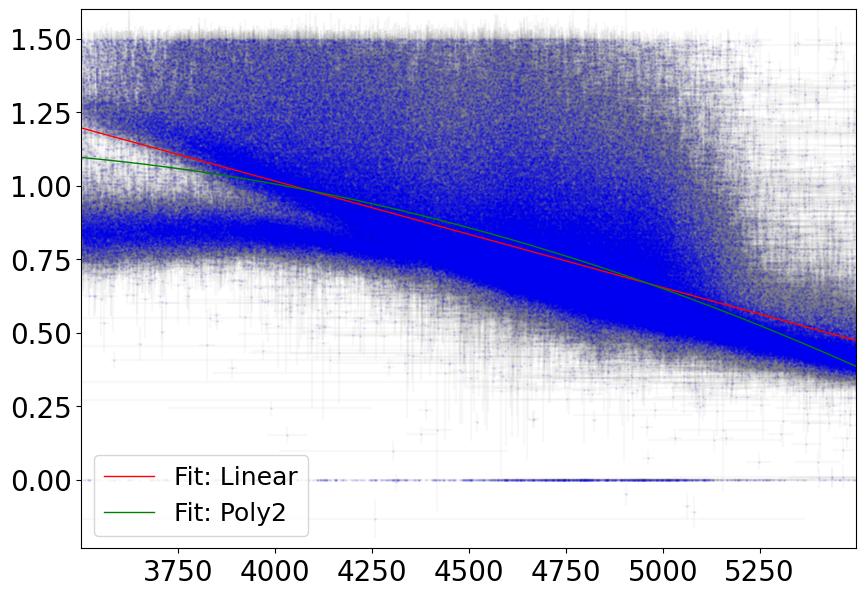

In [17]:
# write your fitting code and plot the results here
# DATA FIT 4

badbits = 2**23
suspectbits = 2**16

# Create (J-K) color and its error
JK = star['J'] - star['K']
JK_ERR = np.sqrt(star['J_ERR']**2 + star['K_ERR']**2)

# Boolean mask
ct1 = (np.bitwise_and(star['aspcapflag'], badbits) == 0) & \
      (np.bitwise_and(star['starflag'], suspectbits) == 0) & \
      (~np.isnan(star['TEFF_ERR'])) & \
      (~np.isnan(JK_ERR)) & \
      (star['TEFF'] > 3500) & (star['TEFF'] < 5500) & \
      (JK > -0.2) & (JK < 1.5) & \
      (JK_ERR < 0.3)

cut1 = np.where(ct1)[0]

# Arrays
teff = star['TEFF'][cut1]
jk = JK[cut1]
teff_err = star['TEFF_ERR'][cut1]
jk_err = JK_ERR[cut1]

# Linear fit
slope, intercept = mcFit2(linear, teff, jk, teff_err, jk_err, p0=[0,0])
print(f"LINEAR: {slope:.4f}, {intercept:.4f}")

# Poly2 fit
poly2A, poly2B, poly2C = mcFit3(poly2, teff, jk, teff_err, jk_err, p0=[0,0,0])
print(f"POLY2: {poly2A:.4f}, {poly2B:.4f}, {poly2C:.4f}")

# Exponential fit (scaled)
teff_mean = teff.mean()
teff_scaled = (teff - teff_mean) / 1000.0

try:
    popt_exp, pcov_exp = opt.curve_fit(exponential, teff_scaled, jk, p0=[0.5, -1.0, 0.0, 0.0], maxfev=20000)
    ExpA, ExpB, ExpC, ExpD = popt_exp
    print(f"EXP: {ExpA:.4f}, {ExpB:.4f}, {ExpC:.4f}, {ExpD:.4f}")
    have_exp = True
except:
    have_exp = False

# Plot
fig1 = plt.figure(figsize=(10,7))
ax1 = fig1.add_subplot(111)
ax1.xaxis.set_tick_params(labelsize=20)
ax1.yaxis.set_tick_params(labelsize=20)

ax1.scatter(teff, jk, s=1, c='b', alpha=0.07)
ax1.errorbar(teff, jk, xerr=teff_err, yerr=jk_err,
             ecolor='grey', fmt='none', alpha=0.05, zorder=0)

x_plot = np.linspace(teff.min(), teff.max(), 1000)

ax1.plot(x_plot, linear(x_plot, slope, intercept), 'r-', lw=1, label='Fit: Linear')
ax1.plot(x_plot, poly2(x_plot, poly2A, poly2B, poly2C), 'g-', lw=1, label='Fit: Poly2')

if have_exp:
    x_scaled = (x_plot - teff_mean) / 1000.0
    ax1.plot(x_plot, exponential(x_scaled, ExpA, ExpB, ExpC, ExpD),
             'y-', lw=1, label='Fit: Exp')

ax1.set_xlim(teff.min(), teff.max())
ax1.set_ylim(jk.min() - 0.1, jk.max() + 0.1)

plt.legend(loc='best', fontsize=18)
plt.show()


## DATA FIT 5

Fit  a linear, a polynomial (poly3), and a cosfit functions and to the following selections of the data:
5. Select stars only with with $-10< GLAT < 10$<br>
   __Fit GLON (0.0001) vs.  VHEILO\_AVG (VERR)__<br>
<br>

For this fit of the above selection:

1. What are the best-fit values of the parameters?
    / Answers: LINEAR: 0.1717, -23.5287
               POLY3: -0.0000, 0.0152, -1.9014, 32.0225
               COSFIT: 49.8461, 0.0198, 1.1843, 8.4735
3. Which fucntion fits the data best? / Answer: The Cos Fit.
4. Is there a second population? (Can you fit outliers with a reasonable linear trend?) / Answer: No there is not second popluation.

LINEAR: 0.1717, -23.5287
POLY3: -0.0000, 0.0152, -1.9014, 32.0225
COSFIT: 49.8461, 0.0198, 1.1843, 8.4735


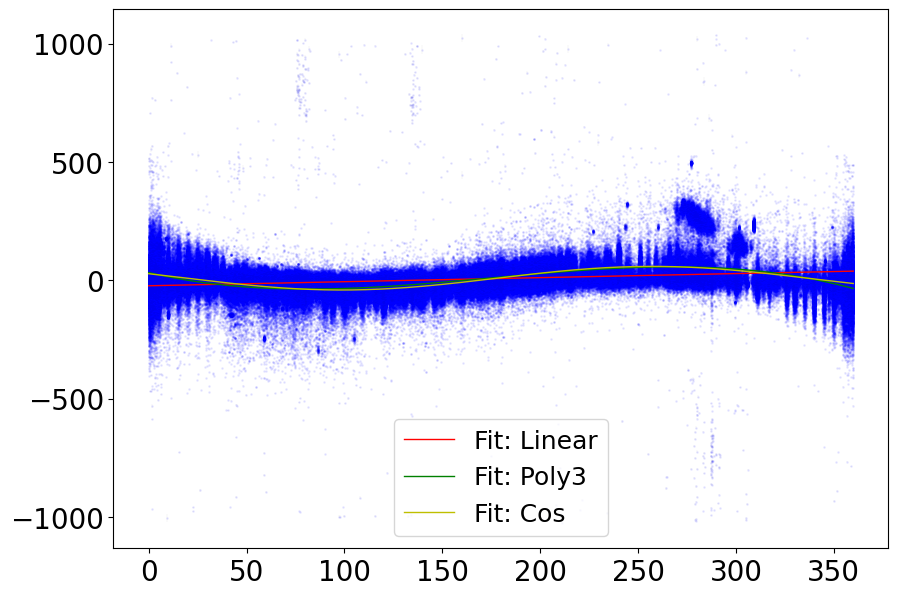

In [18]:
# write your fitting code and plot the results here
# DATA FIT 5

badbits = 2**23        # aspcapstar flag - Chemistry
suspectbits = 2**16    # star flag - Stellar parameters

#=================================================================================
# Make Boolean Mask to remove bad data + required cuts
ct1 = (np.bitwise_and(star['aspcapflag'], badbits) == 0) & \
      (np.bitwise_and(star['starflag'], suspectbits) == 0) & \
      (~np.isnan(star['VHELIO_AVG'])) & \
      (~np.isnan(star['VERR'])) & \
      (star['VERR'] < 20) & \
      (star['GLON'] >= 0) & (star['GLON'] <= 360)

cut1 = np.where(ct1)[0]

# Pull data
x = star['GLON'][cut1]                 # degrees
y = star['VHELIO_AVG'][cut1]          # velocity (km/s)
x_err = np.full_like(x, 0.0001)       # small GLON error
y_err = star['VERR'][cut1]            # velocity errors

#=================================================================================
#Linear fit
slope, intercept = mcFit2(linear, x, y, x_err, y_err, p0=[0,0])
print(f'LINEAR: {slope:.4f}, {intercept:.4f}')

#=================================================================================
#Poly3
poly3A, poly3B, poly3C, poly3D = mcFit4(poly3, x, y, x_err, y_err, p0=[0,0,0,0])
print(f'POLY3: {poly3A:.4f}, {poly3B:.4f}, {poly3C:.4f}, {poly3D:.4f}')

#=================================================================================
#cos
cfA, cfB, cfC, cfD = mcFit4(cosfit, x, y, x_err, y_err, p0=[30, 0.02, 0, 0])
print(f'COSFIT: {cfA:.4f}, {cfB:.4f}, {cfC:.4f}, {cfD:.4f}')

#=================================================================================
#Plot data
fig1 = plt.figure(figsize=(10,7))
ax1 = fig1.add_subplot(111)
ax1.xaxis.set_tick_params(labelsize=20)
ax1.yaxis.set_tick_params(labelsize=20)

ax1.scatter(x, y, s=1, c='b', alpha=0.07)
ax1.errorbar(x, y, xerr=x_err, yerr=y_err, ecolor='grey', fmt='none', alpha=0.04, zorder=0)

#=================================================================================
# PLOT FITS
x_plot = np.linspace(0, 360, 2000)

# linear fit
ax1.plot(x_plot, linear(x_plot, slope, intercept), 'r-', lw=1, label='Fit: Linear')
# poly 3 fit
ax1.plot(x_plot, poly3(x_plot, poly3A, poly3B, poly3C, poly3D), 'g-', lw=1, label='Fit: Poly3')
# cos fit
ax1.plot(x_plot, cosfit(x_plot, cfA, cfB, cfC, cfD), 'y-', lw=1, label='Fit: Cos')

plt.legend(loc='best', fontsize=18)
plt.show()

## DATA FIT 6

Fit  a linear and a polynomial (poly2 AND poly3) functions and to the following selections of the data:
7. __Fit Fe\_H,  (Fe\_H\_ERR)  vs.  NI\_FE (NI\_FE\_ERR)__<br>
<br>

For this fit of the above selection:

1. What are the best-fit values of the parameters?
   / Answers: LINEAR: 0.0127, 0.0156
              POLY2: 0.0245, 0.0377, 0.0168
              POLY3: -0.0212, -0.0184, 0.0261, 0.0183
3. Which fucntion fits the data best? / Answer: The Linear Function
4. Is there a second population? (Can you fit outliers with a reasonable linear trend?) / Answer: No, there is no second population.

LINEAR: 0.0127, 0.0156
POLY2: 0.0245, 0.0377, 0.0168
POLY3: -0.0212, -0.0184, 0.0261, 0.0183


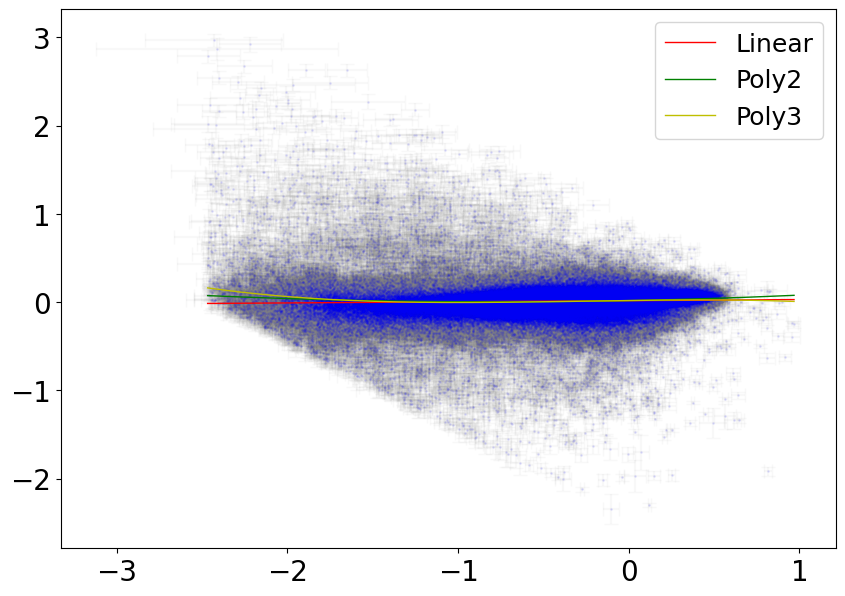

In [19]:
# write your fitting code and plot the results here
# DATA FIT 6

badbits = 2**23        # aspcapstar flag - Chemistry
suspectbits = 2**16    # star flag - Stellar parameters

#=================================================================================
# Make Boolean Mask to remove bad data
ct1 = (np.bitwise_and(star['aspcapflag'], badbits) == 0) & \
      (np.bitwise_and(star['starflag'], suspectbits) == 0) & \
      (~np.isnan(star['FE_H_ERR'])) & \
      (~np.isnan(star['NI_FE_ERR'])) & \
      (star['NI_FE_ERR'] < 0.2)

cut1 = np.where(ct1)[0]

# Pull data
x = star['FE_H'][cut1]
y = star['NI_FE'][cut1]
x_err = star['FE_H_ERR'][cut1]
y_err = star['NI_FE_ERR'][cut1]

#=================================================================================
## LINEAR FIT
slope, intercept = mcFit2(linear, x, y, x_err, y_err, p0=[0,0])
print(f'LINEAR: {slope:.4f}, {intercept:.4f}')

#=================================================================================
## POLY2 FIT (3 parameter)
poly2A, poly2B, poly2C = mcFit3(poly2, x, y, x_err, y_err, p0=[0,0,0])
print(f'POLY2: {poly2A:.4f}, {poly2B:.4f}, {poly2C:.4f}')

#=================================================================================
## POLY3 FIT (4 parameter)
poly3A, poly3B, poly3C, poly3D = mcFit4(poly3, x, y, x_err, y_err, p0=[0,0,0,0])
print(f'POLY3: {poly3A:.4f}, {poly3B:.4f}, {poly3C:.4f}, {poly3D:.4f}')

#=================================================================================
# PLOT DATA
fig1 = plt.figure(figsize=(10,7))
ax1 = fig1.add_subplot(111)
ax1.xaxis.set_tick_params(labelsize=20)
ax1.yaxis.set_tick_params(labelsize=20)

ax1.scatter(x, y, s=1, c='b', alpha=0.08)
ax1.errorbar(x, y,
             xerr=x_err, yerr=y_err,
             ecolor='grey', fmt='none', capsize=5, alpha=0.05, zorder=0)

#=================================================================================
# PLOT FITS
x_plot = np.linspace(x.min(), x.max(), 1000)

# linear fit
ax1.plot(x_plot, linear(x_plot, slope, intercept), 'r-', lw=1, label='Linear')
# poly 2 fit
ax1.plot(x_plot, poly2(x_plot, poly2A, poly2B, poly2C), 'g-', lw=1, label='Poly2')
# poly 3
ax1.plot(x_plot, poly3(x_plot, poly3A, poly3B, poly3C, poly3D), 'y-', lw=1, label='Poly3')

plt.legend(loc='best', fontsize=18)
plt.show()